# Method Comparison Notebook  
## Baseline vs Isolation Forest vs LSTM Autoencoder

This notebook compares the three anomaly-detection methods in one place:

- **Baseline**
- **Isolation Forest**
- **LSTM Autoencoder**

It is designed to align with your current notebooks and their shared conventions:

- selected stocks + selected indices
- anomaly counts and event-peak counts
- consistent plotting style
- comparison-ready summary tables
- side-by-side method analysis for the same instruments

### Main goals

This notebook lets you:

1. load the saved outputs from the three method notebooks,
2. align the result schemas,
3. compare anomaly counts and event-peak counts,
4. inspect score behavior by method,
5. inspect agreement and disagreement between methods,
6. create figures and tables that can be reused in the project report.


## 1. Imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## 2. Configuration

In [3]:
# Lists that match the instruments used in the our 3 notebooks.
STOCK_SERIES = ["AMD", "HIMS", "ORCL", "PLUG"]
INDEX_SERIES = ["SP500", "NASDAQ", "VIX"]
SERIES_TO_RUN = STOCK_SERIES + INDEX_SERIES

# Pick 1 instrument for detailed method-by-method comparison first.
PRIMARY_SERIES = STOCK_SERIES[0]

# Event clustering parameter used to keep Baseline / Isolation Forest consistent
# with the LSTM event-peak concept.
EVENT_GAP_BARS = 3

# Volume style for combined price-volume figures
VOLUME_STYLE = "line"

# Fallback LSTM train end date if it is not present in the loaded results file
LSTM_TRAIN_END_DATE = pd.Timestamp("2024-12-31")

SERIES_TO_RUN, PRIMARY_SERIES


(['AMD', 'HIMS', 'ORCL', 'PLUG', 'SP500', 'NASDAQ', 'VIX'], 'AMD')

## 3. File paths

This section tries a few candidate locations for each method.

You may need to adjust these paths depending on where your notebooks saved their outputs.


In [4]:
# Example:
# PROJECT_ROOT = Path(r"G:\My Drive\MSc. in Data Science\S4 Project in Data Science\project")
PROJECT_ROOT = Path(".")

def resolve_first_existing(candidates):
    for p in candidates:
        p = Path(p)
        if p.exists():
            return p
    return Path(candidates[0])

FEATURES_PATH = resolve_first_existing([
    PROJECT_ROOT / "data" / "processed" / "market_data_features_2021_2026.csv",
    Path("data/processed/market_data_features_2021_2026.csv"),
])

BASELINE_RESULTS_PATH = resolve_first_existing([
    PROJECT_ROOT / "results" / "notebooks" / "baseline_aligned" / "baseline_results_selected.csv",
    PROJECT_ROOT / "data" / "processed" / "baseline_anomaly_results.csv",
    Path("results/notebooks/baseline_aligned/baseline_results_selected.csv"),
    Path("data/processed/baseline_anomaly_results.csv"),
])

IFOREST_RESULTS_PATH = resolve_first_existing([
    PROJECT_ROOT / "results" / "notebooks" / "isolation_forest_aligned" / "isolation_forest_results_selected.csv",
    PROJECT_ROOT / "data" / "processed" / "isolation_forest_results.csv",
    Path("results/notebooks/isolation_forest_aligned/isolation_forest_results_selected.csv"),
    Path("data/processed/isolation_forest_results.csv"),
])

LSTM_RESULTS_PATH = resolve_first_existing([
    PROJECT_ROOT / "results" / "notebooks" / "lstm_single_stock" / "lstm_results_SINGLE_STOCK.csv",
    PROJECT_ROOT / "data" / "processed" / "lstm_autoencoder_results.csv",
    Path("results/notebooks/lstm_single_stock/lstm_results_SINGLE_STOCK.csv"),
    Path("data/processed/lstm_autoencoder_results.csv"),
])

OUTPUT_DIR = resolve_first_existing([
    PROJECT_ROOT / "results" / "notebooks" / "method_comparison",
    Path("results/notebooks/method_comparison"),
])
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COMPARISON_RESULTS_PATH = OUTPUT_DIR / "method_comparison_results.csv"
COMPARISON_SUMMARY_PATH = OUTPUT_DIR / "method_comparison_summary.csv"
CONSENSUS_PATH = OUTPUT_DIR / "method_consensus_table.csv"

FEATURES_PATH, BASELINE_RESULTS_PATH, IFOREST_RESULTS_PATH, LSTM_RESULTS_PATH, OUTPUT_DIR


(WindowsPath('data/processed/market_data_features_2021_2026.csv'),
 WindowsPath('results/notebooks/baseline_aligned/baseline_results_selected.csv'),
 WindowsPath('data/processed/isolation_forest_results.csv'),
 WindowsPath('results/notebooks/lstm_single_stock/lstm_results_SINGLE_STOCK.csv'),
 WindowsPath('results/notebooks/method_comparison'))

## 4. Load datasets

In [5]:
if not FEATURES_PATH.exists():
    raise FileNotFoundError(f"Features file not found: {FEATURES_PATH}")
if not BASELINE_RESULTS_PATH.exists():
    raise FileNotFoundError(f"Baseline results file not found: {BASELINE_RESULTS_PATH}")
if not IFOREST_RESULTS_PATH.exists():
    raise FileNotFoundError(f"Isolation Forest results file not found: {IFOREST_RESULTS_PATH}")
if not LSTM_RESULTS_PATH.exists():
    raise FileNotFoundError(f"LSTM results file not found: {LSTM_RESULTS_PATH}")

features_df = pd.read_csv(FEATURES_PATH, parse_dates=["Date"], low_memory=False)
baseline_df = pd.read_csv(BASELINE_RESULTS_PATH, parse_dates=["Date"], low_memory=False)
iforest_df = pd.read_csv(IFOREST_RESULTS_PATH, parse_dates=["Date"], low_memory=False)
lstm_df = pd.read_csv(LSTM_RESULTS_PATH, parse_dates=["Date"], low_memory=False)

print("Features shape:", features_df.shape)
print("Baseline shape:", baseline_df.shape)
print("Isolation Forest shape:", iforest_df.shape)
print("LSTM shape:", lstm_df.shape)


Features shape: (19770, 74)
Baseline shape: (7908, 39)
Isolation Forest shape: (19770, 55)
LSTM shape: (7908, 88)


## 5. Restrict to the selected stocks and indices

In [6]:
features_subset = features_df[features_df["SeriesName"].isin(SERIES_TO_RUN)].copy()
baseline_subset = baseline_df[baseline_df["SeriesName"].isin(SERIES_TO_RUN)].copy()
iforest_subset = iforest_df[iforest_df["SeriesName"].isin(SERIES_TO_RUN)].copy()
lstm_subset = lstm_df[lstm_df["SeriesName"].isin(SERIES_TO_RUN)].copy()

features_subset = features_subset.sort_values(["SeriesName", "Date"]).reset_index(drop=True)
baseline_subset = baseline_subset.sort_values(["SeriesName", "Date"]).reset_index(drop=True)
iforest_subset = iforest_subset.sort_values(["SeriesName", "Date"]).reset_index(drop=True)
lstm_subset = lstm_subset.sort_values(["SeriesName", "Date"]).reset_index(drop=True)

print("Series in scope:", SERIES_TO_RUN)
print("Baseline subset shape:", baseline_subset.shape)
print("Isolation Forest subset shape:", iforest_subset.shape)
print("LSTM subset shape:", lstm_subset.shape)


Series in scope: ['AMD', 'HIMS', 'ORCL', 'PLUG', 'SP500', 'NASDAQ', 'VIX']
Baseline subset shape: (7908, 39)
Isolation Forest subset shape: (9226, 55)
LSTM subset shape: (7908, 88)


## 6. Merge commonly used feature columns into all method outputs

In [7]:
merge_cols = [
    "Date", "Ticker", "SeriesName",
    "Price", "Volume",
    "simple_return", "return_5d", "return_10d",
    "ma_5", "ma_20", "ma_60",
    "vol_5", "vol_20", "vol_60",
    "dist_ma_20", "dist_ma_60",
    "z_simple_return_20", "z_return_20",
    "volume_z_20", "relative_volume_20",
    "SP500_simple_return", "NASDAQ_simple_return",
    "VIX_level", "VIX_simple_return", "VIX_z_simple_20",
    "excess_simple_return_sp500", "excess_simple_return_nasdaq",
]

available_merge_cols = [c for c in merge_cols if c in features_subset.columns]

def enrich_with_features(df_in):
    return df_in.merge(
        features_subset[available_merge_cols].copy(),
        on=["Date", "Ticker", "SeriesName"],
        how="left",
        suffixes=("", "_feat"),
    )

baseline_subset = enrich_with_features(baseline_subset)
iforest_subset = enrich_with_features(iforest_subset)
lstm_subset = enrich_with_features(lstm_subset)

display(baseline_subset.head())


,Date,SeriesName,Ticker,Price,z_return_20,volume_z_20,return_component,volume_component,baseline_score,flag_return_only,flag_volume_only,baseline_threshold,is_anomaly,Volume,Price_feat,simple_return,return_5d,return_10d,ma_5,ma_20,ma_60,vol_5,vol_20,vol_60,dist_ma_20,dist_ma_60,z_simple_return_20,z_return_20_feat,volume_z_20_feat,relative_volume_20,SP500_simple_return,NASDAQ_simple_return,VIX_level,VIX_simple_return,VIX_z_simple_20,excess_simple_return_sp500,excess_simple_return_nasdaq,baseline_event_group,baseline_is_event_peak,Price_feat,Volume_feat,simple_return_feat,return_5d_feat,return_10d_feat,ma_5_feat,ma_20_feat,ma_60_feat,vol_5_feat,vol_20_feat,vol_60_feat,dist_ma_20_feat,dist_ma_60_feat,z_simple_return_20_feat,z_return_20_feat,volume_z_20_feat,relative_volume_20_feat,SP500_simple_return_feat,NASDAQ_simple_return_feat,VIX_level_feat,VIX_simple_return_feat,VIX_z_simple_20_feat,excess_simple_return_sp500_feat,excess_simple_return_nasdaq_feat
0,2021-01-04,AMD,AMD,92.300003,0.386154,1.203970,0.386154,1.203970,0.631499,False,False,2.868576,False,51802600.0,92.300003,0.006433,0.005337,-0.046881,91.704001,93.197501,86.520000,0.010292,0.016621,0.023782,-0.009630,0.066805,0.378940,0.386154,1.203970,1.384963,-0.014755,-0.014729,26.969999,0.185494,2.546176,0.021188,0.021162,NaN,False,92.300003,51802600.0,0.006433,0.005337,-0.046881,91.704001,93.197501,86.520000,0.010292,0.016621,0.023782,-0.009630,0.066805,0.378940,0.386154,1.203970,1.384963,-0.014755,-0.014729,26.969999,0.185494,2.546176,0.021188,0.021162
1,2021-01-05,AMD,AMD,92.769997,0.357266,-0.097812,0.357266,0.097812,0.279430,False,False,2.868576,False,34208000.0,92.769997,0.005092,0.012773,-0.032840,91.938000,93.134000,86.624333,0.010233,0.016120,0.023784,-0.003908,0.070946,0.349949,0.357266,-0.097812,0.928670,0.007083,0.009490,25.340000,-0.060437,-1.054928,-0.001991,-0.004398,NaN,False,92.769997,34208000.0,0.005092,0.012773,-0.032840,91.938000,93.134000,86.624333,0.010233,0.016120,0.023784,-0.003908,0.070946,0.349949,0.357266,-0.097812,0.928670,0.007083,0.009490,25.340000,-0.060437,-1.054928,-0.001991,-0.004398
2,2021-01-06,AMD,AMD,90.330002,-1.441814,1.192347,1.441814,1.192347,1.366974,False,False,2.868576,False,51911700.0,90.330002,-0.026302,-0.003200,-0.031106,91.880000,92.947001,86.744833,0.015156,0.017079,0.023452,-0.028156,0.041330,-1.430945,-1.441814,1.192347,1.386520,0.005710,-0.006098,25.070000,-0.010655,-0.305710,-0.032011,-0.020204,NaN,False,90.330002,51911700.0,-0.026302,-0.003200,-0.031106,91.880000,92.947001,86.744833,0.015156,0.017079,0.023452,-0.028156,0.041330,-1.430945,-1.441814,1.192347,1.386520,0.005710,-0.006098,25.070000,-0.010655,-0.305710,-0.032011,-0.020204
3,2021-01-07,AMD,AMD,95.160004,2.476254,0.543188,2.476254,0.543188,1.896334,False,False,2.868576,False,42897200.0,95.160004,0.053471,0.031098,0.021468,92.454001,93.059001,86.926000,0.025857,0.020555,0.024283,0.022577,0.094724,2.515840,2.476254,0.543188,1.132158,0.014847,0.025641,22.370001,-0.107698,-1.560001,0.038623,0.027829,NaN,False,95.160004,42897200.0,0.053471,0.031098,0.021468,92.454001,93.059001,86.926000,0.025857,0.020555,0.024283,0.022577,0.094724,2.515840,2.476254,0.543188,1.132158,0.014847,0.025641,22.370001,-0.107698,-1.560001,0.038623,0.027829
4,2021-01-08,AMD,AMD,94.580002,-0.456761,0.362030,0.456761,0.362030,0.428342,False,False,2.868576,False,39816400.0,94.580002,-0.006095,0.031294,0.033097,93.028001,93.296501,87.081000,0.025839,0.019025,0.024272,0.013757,0.086115,-0.460945,-0.456761,0.362030,1.068264,0.005492,0.010293,21.559999,-0.036209,-0.515276,-0.011587,-0.016388,NaN,False,94.580002,39816400.0,-0.006095,0.031294,0.033097,93.028001,93.296501,87.081000,0.025839,0.019025,0.024272,0.013757,0.086115,-0.460945,-0.456761,0.362030,1.068264,0.005492,0.010293,21.559999,-0.036209,-0.515276,-0.011587,-0.016388


## 7. Helper functions to align the schemas

In [8]:
def millions_formatter(x, pos):
    return f"{x / 1_000_000:.0f}M"


def add_event_peaks_from_flag(
    df_in: pd.DataFrame,
    flag_col: str,
    score_col: str,
    peak_col: str,
    group_col: str,
    gap_bars: int = EVENT_GAP_BARS,
) -> pd.DataFrame:
    df = df_in.sort_values("Date").copy()
    df[group_col] = np.nan
    df[peak_col] = False

    anomaly_idx = df.index[df[flag_col].fillna(False)].to_list()
    if not anomaly_idx:
        return df

    group_ids = []
    current_group = 0
    prev_idx = anomaly_idx[0]

    for i, idx in enumerate(anomaly_idx):
        if i == 0:
            group_ids.append(current_group)
            continue

        if (idx - prev_idx) <= gap_bars:
            group_ids.append(current_group)
        else:
            current_group += 1
            group_ids.append(current_group)

        prev_idx = idx

    df.loc[anomaly_idx, group_col] = group_ids

    event_peak_idx = (
        df.loc[anomaly_idx]
        .groupby(group_col)[score_col]
        .idxmax()
    )
    df.loc[event_peak_idx, peak_col] = True

    return df


def standardize_baseline(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()

    if "baseline_is_event_peak" not in df.columns:
        parts = []
        for _, g in df.groupby("SeriesName", sort=False):
            parts.append(
                add_event_peaks_from_flag(
                    g,
                    flag_col="is_anomaly",
                    score_col="baseline_score",
                    peak_col="baseline_is_event_peak",
                    group_col="baseline_event_group",
                )
            )
        df = pd.concat(parts, ignore_index=True)

    df["method"] = "Baseline"
    df["score"] = df["baseline_score"]
    df["threshold"] = df["baseline_threshold"] if "baseline_threshold" in df.columns else np.nan
    df["is_anomaly_detected"] = df["is_anomaly"].astype(bool)
    df["is_event_peak_detected"] = df["baseline_is_event_peak"].astype(bool)
    df["train_end_date"] = pd.NaT

    keep_cols = [
        "method", "Date", "SeriesName", "Ticker", "Price", "Volume",
        "score", "threshold", "is_anomaly_detected", "is_event_peak_detected", "train_end_date"
    ]
    extra_cols = [c for c in [
        "simple_return", "return_5d", "return_10d",
        "ma_5", "ma_20", "ma_60",
        "vol_5", "vol_20", "vol_60",
        "dist_ma_20", "dist_ma_60",
        "volume_z_20", "relative_volume_20",
        "SP500_simple_return", "NASDAQ_simple_return",
        "VIX_level", "VIX_simple_return", "VIX_z_simple_20",
        "excess_simple_return_sp500", "excess_simple_return_nasdaq",
    ] if c in df.columns]
    return df[keep_cols + extra_cols].copy()


def standardize_iforest(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()

    if "iforest_is_event_peak" not in df.columns:
        parts = []
        for _, g in df.groupby("SeriesName", sort=False):
            parts.append(
                add_event_peaks_from_flag(
                    g,
                    flag_col="iforest_is_anomaly",
                    score_col="iforest_score",
                    peak_col="iforest_is_event_peak",
                    group_col="iforest_event_group",
                )
            )
        df = pd.concat(parts, ignore_index=True)

    df["method"] = "Isolation Forest"
    df["score"] = df["iforest_score"]

    # Use the minimum detected score as an effective cutoff if an explicit threshold is not stored.
    if "effective_score_cutoff" in df.columns:
        df["threshold"] = df["effective_score_cutoff"]
    else:
        df["threshold"] = np.nan
        for _, g in df.groupby("SeriesName"):
            mask = g["iforest_is_anomaly"].fillna(False)
            cutoff = g.loc[mask, "iforest_score"].min() if mask.any() else np.nan
            df.loc[g.index, "threshold"] = cutoff

    df["is_anomaly_detected"] = df["iforest_is_anomaly"].astype(bool)
    df["is_event_peak_detected"] = df["iforest_is_event_peak"].astype(bool)

    if "iforest_train_end_date" in df.columns:
        df["train_end_date"] = pd.to_datetime(df["iforest_train_end_date"])
    else:
        df["train_end_date"] = pd.NaT

    keep_cols = [
        "method", "Date", "SeriesName", "Ticker", "Price", "Volume",
        "score", "threshold", "is_anomaly_detected", "is_event_peak_detected", "train_end_date"
    ]
    extra_cols = [c for c in [
        "simple_return", "return_5d", "return_10d",
        "ma_5", "ma_20", "ma_60",
        "vol_5", "vol_20", "vol_60",
        "dist_ma_20", "dist_ma_60",
        "volume_z_20", "relative_volume_20",
        "SP500_simple_return", "NASDAQ_simple_return",
        "VIX_level", "VIX_simple_return", "VIX_z_simple_20",
        "excess_simple_return_sp500", "excess_simple_return_nasdaq",
    ] if c in df.columns]
    return df[keep_cols + extra_cols].copy()


def standardize_lstm(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()

    # If event peaks are missing, derive them from detected anomalies.
    if "lstm_is_event_peak" not in df.columns:
        parts = []
        for _, g in df.groupby("SeriesName", sort=False):
            parts.append(
                add_event_peaks_from_flag(
                    g,
                    flag_col="lstm_is_anomaly",
                    score_col="lstm_score",
                    peak_col="lstm_is_event_peak",
                    group_col="lstm_event_group",
                )
            )
        df = pd.concat(parts, ignore_index=True)

    df["method"] = "LSTM Autoencoder"
    df["score"] = df["lstm_score"]
    df["threshold"] = df["lstm_threshold"] if "lstm_threshold" in df.columns else np.nan

    if "lstm_is_anomaly" in df.columns:
        df["is_anomaly_detected"] = df["lstm_is_anomaly"].astype(bool)
    else:
        df["is_anomaly_detected"] = False

    df["is_event_peak_detected"] = df["lstm_is_event_peak"].astype(bool)

    if "lstm_train_end_date" in df.columns:
        df["train_end_date"] = pd.to_datetime(df["lstm_train_end_date"])
    else:
        df["train_end_date"] = LSTM_TRAIN_END_DATE

    keep_cols = [
        "method", "Date", "SeriesName", "Ticker", "Price", "Volume",
        "score", "threshold", "is_anomaly_detected", "is_event_peak_detected", "train_end_date"
    ]
    extra_cols = [c for c in [
        "simple_return", "return_5d", "return_10d",
        "ma_5", "ma_20", "ma_60",
        "vol_5", "vol_20", "vol_60",
        "dist_ma_20", "dist_ma_60",
        "volume_z_20", "relative_volume_20",
        "SP500_simple_return", "NASDAQ_simple_return",
        "VIX_level", "VIX_simple_return", "VIX_z_simple_20",
        "excess_simple_return_sp500", "excess_simple_return_nasdaq",
    ] if c in df.columns]
    return df[keep_cols + extra_cols].copy()


## 8. Standardize the three method outputs and combine them

In [9]:
baseline_std = standardize_baseline(baseline_subset)
iforest_std = standardize_iforest(iforest_subset)
lstm_std = standardize_lstm(lstm_subset)

comparison_df = pd.concat([baseline_std, iforest_std, lstm_std], ignore_index=True)
comparison_df = comparison_df.sort_values(["SeriesName", "method", "Date"]).reset_index(drop=True)

print("Combined comparison dataframe shape:", comparison_df.shape)
display(comparison_df.head())


Combined comparison dataframe shape: (25042, 31)


,method,Date,SeriesName,Ticker,Price,Volume,score,threshold,is_anomaly_detected,is_event_peak_detected,train_end_date,simple_return,return_5d,return_10d,ma_5,ma_20,ma_60,vol_5,vol_20,vol_60,dist_ma_20,dist_ma_60,volume_z_20,relative_volume_20,SP500_simple_return,NASDAQ_simple_return,VIX_level,VIX_simple_return,VIX_z_simple_20,excess_simple_return_sp500,excess_simple_return_nasdaq
0,Baseline,2021-01-04,AMD,AMD,92.300003,51802600.0,0.631499,2.868576,False,False,NaT,0.006433,0.005337,-0.046881,91.704001,93.197501,86.520000,0.010292,0.016621,0.023782,-0.009630,0.066805,1.203970,1.384963,-0.014755,-0.014729,26.969999,0.185494,2.546176,0.021188,0.021162
1,Baseline,2021-01-05,AMD,AMD,92.769997,34208000.0,0.279430,2.868576,False,False,NaT,0.005092,0.012773,-0.032840,91.938000,93.134000,86.624333,0.010233,0.016120,0.023784,-0.003908,0.070946,-0.097812,0.928670,0.007083,0.009490,25.340000,-0.060437,-1.054928,-0.001991,-0.004398
2,Baseline,2021-01-06,AMD,AMD,90.330002,51911700.0,1.366974,2.868576,False,False,NaT,-0.026302,-0.003200,-0.031106,91.880000,92.947001,86.744833,0.015156,0.017079,0.023452,-0.028156,0.041330,1.192347,1.386520,0.005710,-0.006098,25.070000,-0.010655,-0.305710,-0.032011,-0.020204
3,Baseline,2021-01-07,AMD,AMD,95.160004,42897200.0,1.896334,2.868576,False,False,NaT,0.053471,0.031098,0.021468,92.454001,93.059001,86.926000,0.025857,0.020555,0.024283,0.022577,0.094724,0.543188,1.132158,0.014847,0.025641,22.370001,-0.107698,-1.560001,0.038623,0.027829
4,Baseline,2021-01-08,AMD,AMD,94.580002,39816400.0,0.428342,2.868576,False,False,NaT,-0.006095,0.031294,0.033097,93.028001,93.296501,87.081000,0.025839,0.019025,0.024272,0.013757,0.086115,0.362030,1.068264,0.005492,0.010293,21.559999,-0.036209,-0.515276,-0.011587,-0.016388


## 9. Build aligned summary tables

In [10]:
comparison_summary = (
    comparison_df.groupby(["method", "SeriesName", "Ticker"], as_index=False)
    .agg(
        n_rows=("Date", "count"),
        n_anomalies_detected=("is_anomaly_detected", "sum"),
        n_event_peaks_detected=("is_event_peak_detected", "sum"),
        anomaly_rate_detected=("is_anomaly_detected", "mean"),
        event_peak_rate_detected=("is_event_peak_detected", "mean"),
        avg_score=("score", "mean"),
        max_score=("score", "max"),
        threshold=("threshold", "max"),
    )
    .sort_values(["SeriesName", "method"])
    .reset_index(drop=True)
)

count_pivot = comparison_summary.pivot(
    index="SeriesName",
    columns="method",
    values="n_anomalies_detected"
)

event_peak_pivot = comparison_summary.pivot(
    index="SeriesName",
    columns="method",
    values="n_event_peaks_detected"
)

display(comparison_summary)
display(count_pivot)
display(event_peak_pivot)


,method,SeriesName,Ticker,n_rows,n_anomalies_detected,n_event_peaks_detected,anomaly_rate_detected,event_peak_rate_detected,avg_score,max_score,threshold
0,Baseline,AMD,AMD,1318,14,14,0.010622,0.010622,0.814318,3.982930,2.868576e+00
1,Isolation Forest,AMD,AMD,1318,19,13,0.014416,0.009863,-0.179626,0.087496,3.223517e-04
2,LSTM Autoencoder,AMD,AMD,1318,13,9,0.009863,0.006829,0.560961,40.458090,2.720391e+00
3,Baseline,HIMS,HIMS,1318,14,14,0.010622,0.010622,0.808541,3.719917,2.805454e+00
4,Isolation Forest,HIMS,HIMS,1318,23,15,0.017451,0.011381,-0.181368,0.083104,4.648933e-04
5,LSTM Autoencoder,HIMS,HIMS,1318,11,8,0.008346,0.006070,0.818515,51.924776,5.087439e+00
6,Baseline,NASDAQ,^IXIC,1318,14,14,0.010622,0.010622,0.813740,2.982625,2.289479e+00
7,Isolation Forest,NASDAQ,^IXIC,1318,17,11,0.012898,0.008346,-0.197148,0.080585,3.236020e-05
8,Baseline,ORCL,ORCL,1318,14,14,0.010622,0.010622,0.801163,3.889685,2.970540e+00
9,Isolation Forest,ORCL,ORCL,1318,37,24,0.028073,0.018209,-0.178805,0.114707,4.129922e-07


method,Baseline,Isolation Forest,LSTM Autoencoder
SeriesName,,,
AMD,14.0,19.0,13.0
HIMS,14.0,23.0,11.0
NASDAQ,14.0,17.0,NaN
ORCL,14.0,37.0,7.0
PLUG,NaN,19.0,13.0
SP500,14.0,17.0,13.0
VIX,14.0,17.0,10.0


method,Baseline,Isolation Forest,LSTM Autoencoder
SeriesName,,,
AMD,14.0,13.0,9.0
HIMS,14.0,15.0,8.0
NASDAQ,14.0,11.0,NaN
ORCL,14.0,24.0,6.0
PLUG,NaN,15.0,8.0
SP500,11.0,10.0,7.0
VIX,13.0,8.0,5.0


## 10. Save the aligned comparison tables

In [11]:
comparison_df.to_csv(COMPARISON_RESULTS_PATH, index=False)
comparison_summary.to_csv(COMPARISON_SUMMARY_PATH, index=False)

print(f"Saved comparison results to: {COMPARISON_RESULTS_PATH}")
print(f"Saved comparison summary to: {COMPARISON_SUMMARY_PATH}")


Saved comparison results to: results\notebooks\method_comparison\method_comparison_results.csv
Saved comparison summary to: results\notebooks\method_comparison\method_comparison_summary.csv


## 11. Method-comparison plotting helpers

In [12]:
def get_method_series_data(df_in: pd.DataFrame, method: str, series_name: str) -> pd.DataFrame:
    out = df_in[(df_in["method"] == method) & (df_in["SeriesName"] == series_name)].sort_values("Date").copy()
    if out.empty:
        raise ValueError(f"No data found for method={method}, series={series_name}")
    return out


def add_train_region(ax, group: pd.DataFrame):
    train_end_vals = group["train_end_date"].dropna().unique()
    if len(train_end_vals) > 0:
        train_end = pd.Timestamp(train_end_vals[0])
        ax.axvspan(group["Date"].min(), train_end, color="lightgrey", alpha=0.15, label="Training period")
        ax.axvline(train_end, color="green", linestyle="-", linewidth=2.0, alpha=0.9, label="Train end")


def plot_method_price_comparison(series_name: str, df_in: pd.DataFrame):
    methods = ["Baseline", "Isolation Forest", "LSTM Autoencoder"]
    fig, axes = plt.subplots(len(methods), 1, figsize=(15, 13), sharex=True)

    for ax, method in zip(axes, methods):
        group = get_method_series_data(df_in, method, series_name)
        anomalies = group[group["is_anomaly_detected"]].copy()
        peaks = group[group["is_event_peak_detected"]].copy()

        ax.plot(group["Date"], group["Price"], color="blue", linewidth=1.5, label="Price")
        add_train_region(ax, group)

        for d in anomalies["Date"]:
            ax.axvline(d, color="grey", linestyle="--", linewidth=0.8, alpha=0.45, zorder=1)

        if not anomalies.empty:
            ax.scatter(anomalies["Date"], anomalies["Price"], color="red", s=28, alpha=0.95, label="Anomaly", zorder=4)

        if not peaks.empty:
            ax.scatter(peaks["Date"], peaks["Price"], color="yellow", edgecolor="black", marker="^",
                       s=110, alpha=1.0, label="Event peak", zorder=5)

        ax.set_title(f"{series_name} - {method}", pad=14)
        ax.set_ylabel("Price")
        ax.legend()

    axes[-1].set_xlabel("Date")
    plt.tight_layout()
    plt.show()


def plot_method_score_comparison(series_name: str, df_in: pd.DataFrame):
    methods = ["Baseline", "Isolation Forest", "LSTM Autoencoder"]
    fig, axes = plt.subplots(len(methods), 1, figsize=(15, 13), sharex=True)

    for ax, method in zip(axes, methods):
        group = get_method_series_data(df_in, method, series_name)

        ax.plot(group["Date"], group["score"], linewidth=1.2, label="score")
        if group["threshold"].notna().any():
            ax.axhline(group["threshold"].dropna().iloc[0], linestyle="--", label="threshold")

        add_train_region(ax, group)
        ax.set_title(f"{series_name} - {method} score", pad=14)
        ax.set_ylabel("Score")
        ax.legend()

    axes[-1].set_xlabel("Date")
    plt.tight_layout()
    plt.show()


def plot_method_counts_for_series(df_summary: pd.DataFrame, series_name: str):
    sub = df_summary[df_summary["SeriesName"] == series_name].copy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    bars = axes[0].bar(sub["method"], sub["n_anomalies_detected"])
    axes[0].set_title(f"{series_name} - n_anomalies_detected", pad=20)
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=15)
    for bar, val in zip(bars, sub["n_anomalies_detected"]):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{int(val)}",
                     ha="center", va="bottom", fontsize=10)

    bars = axes[1].bar(sub["method"], sub["n_event_peaks_detected"])
    axes[1].set_title(f"{series_name} - n_event_peaks_detected", pad=20)
    axes[1].set_ylabel("Count")
    axes[1].tick_params(axis="x", rotation=15)
    for bar, val in zip(bars, sub["n_event_peaks_detected"]):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{int(val)}",
                     ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.show()


## 12. Compare one selected series in depth

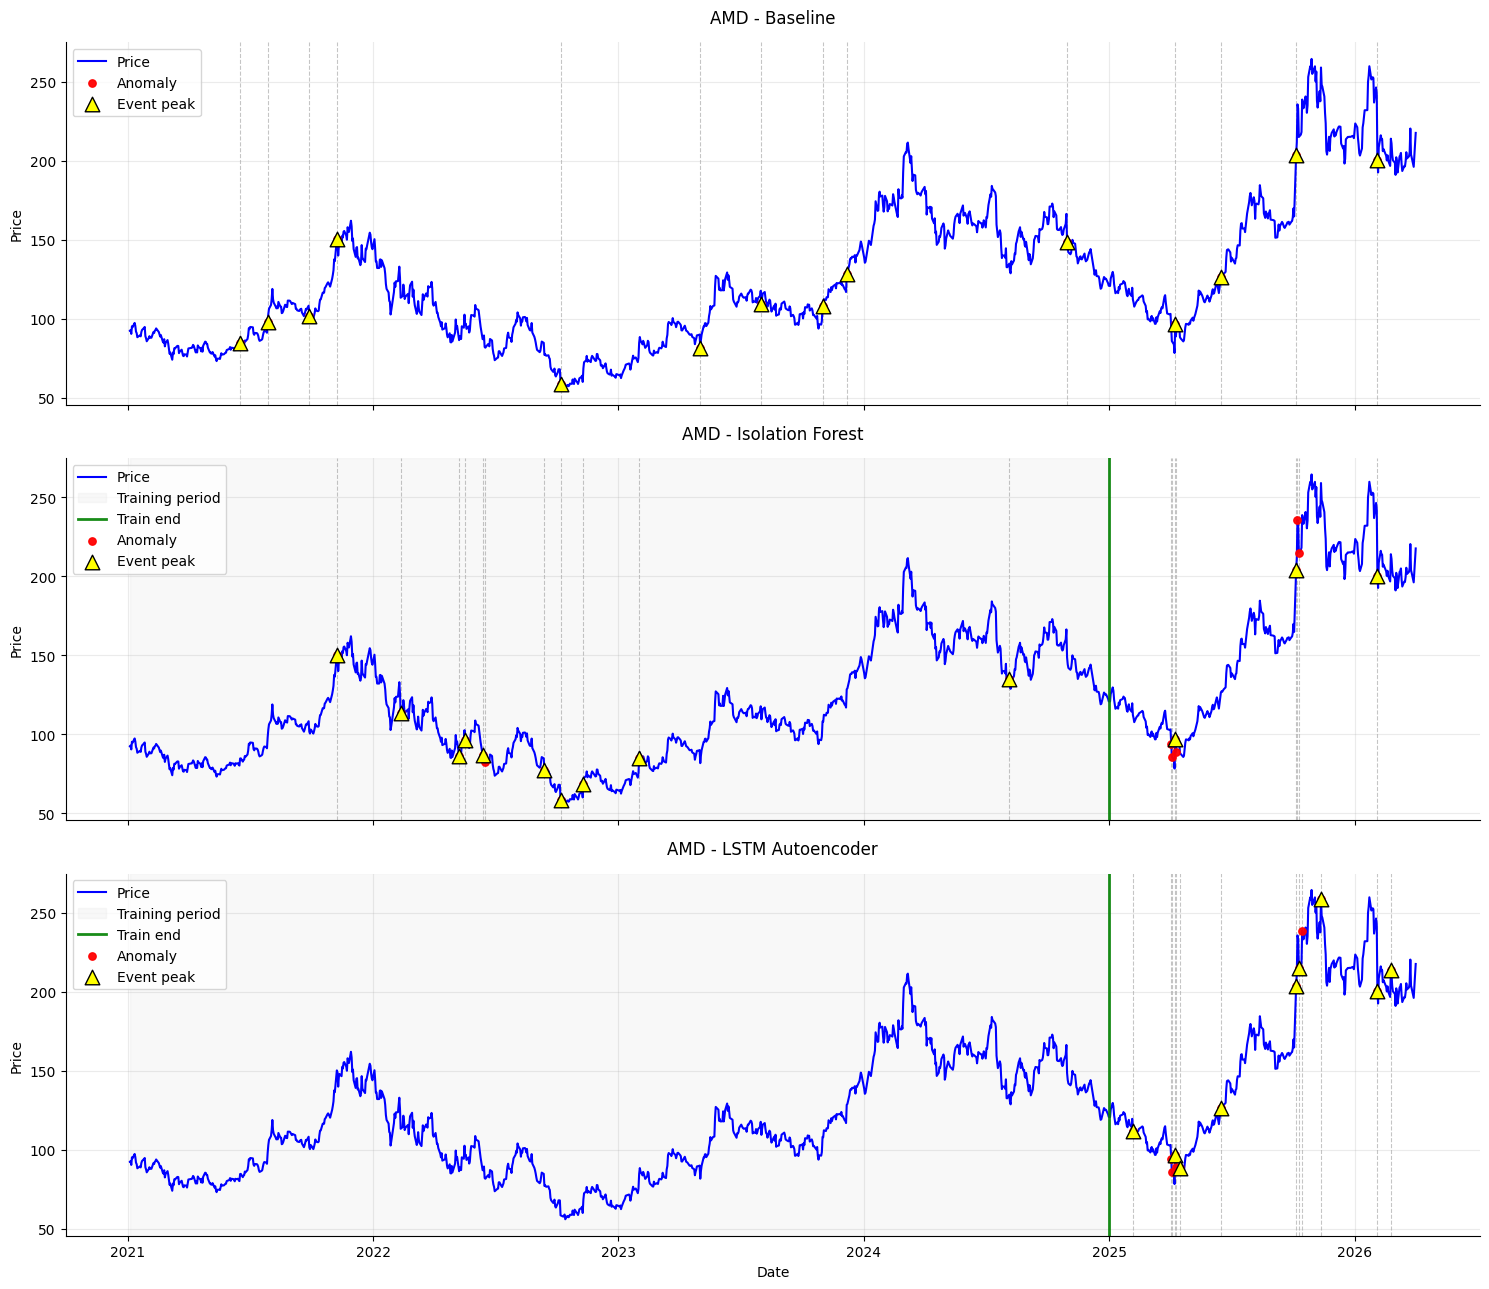

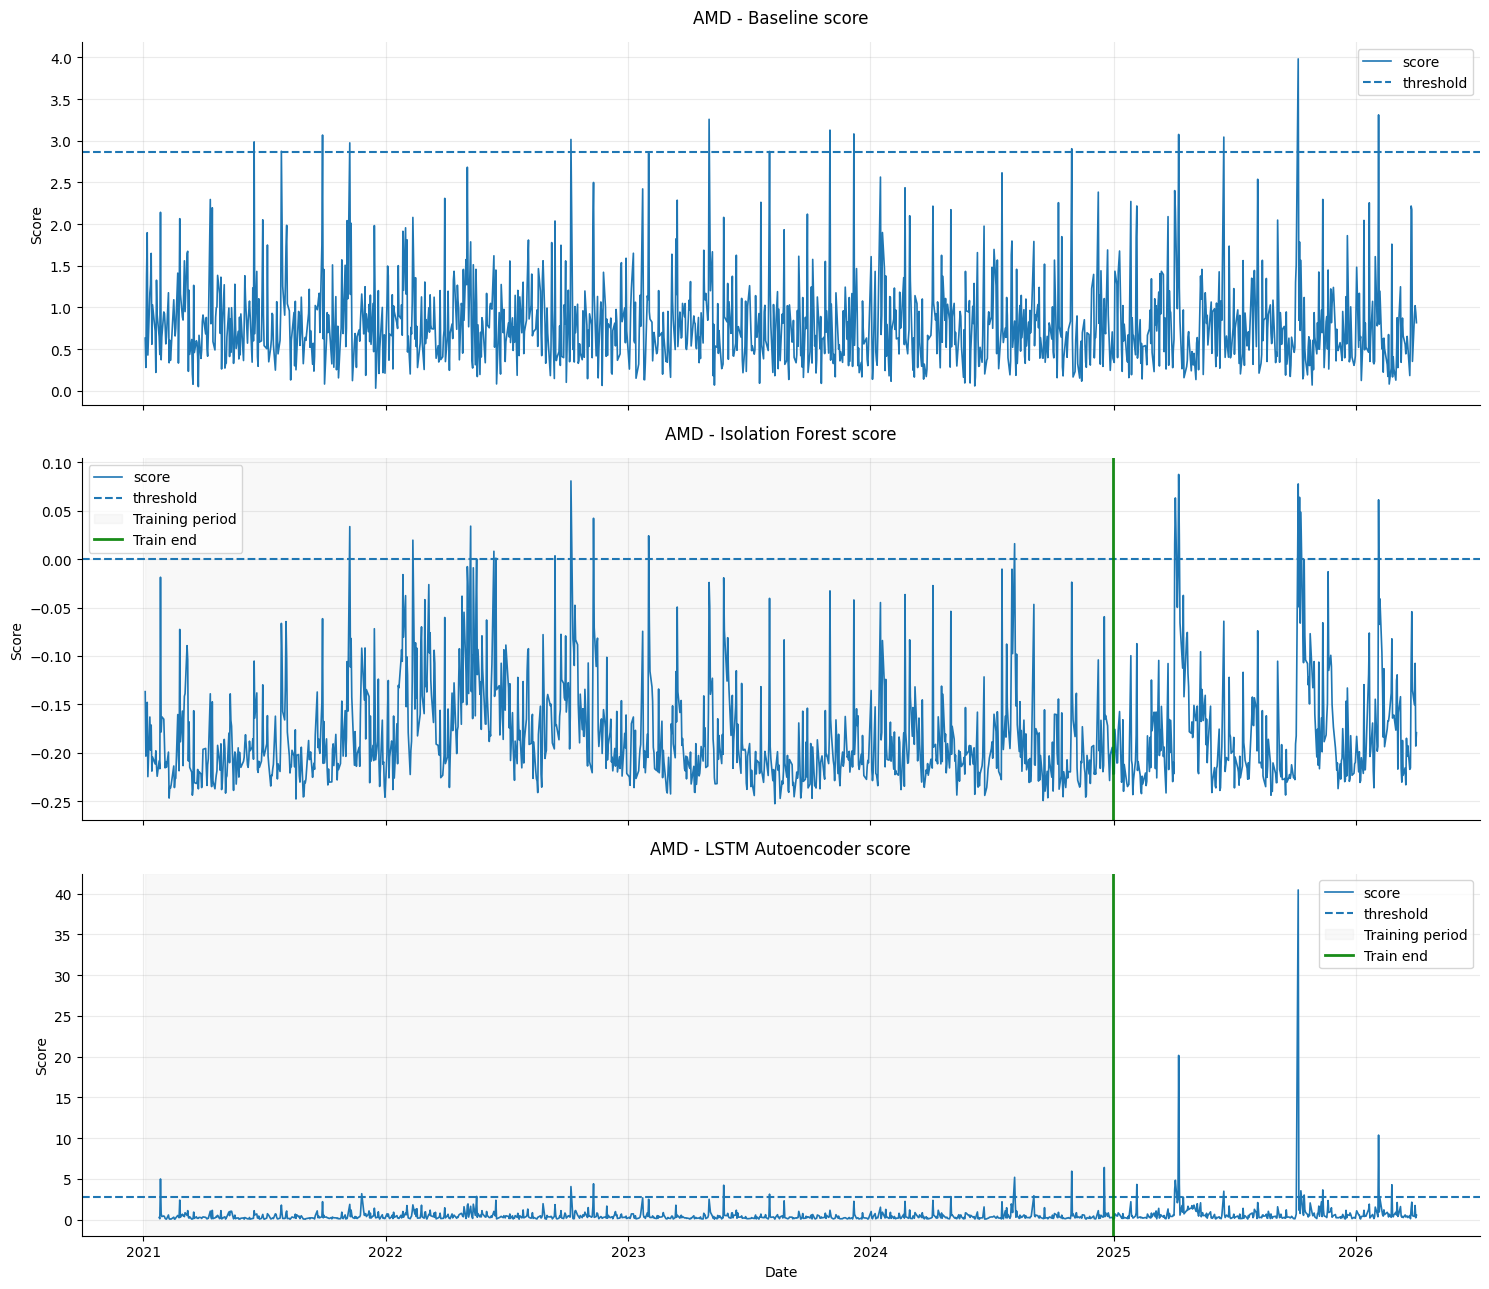

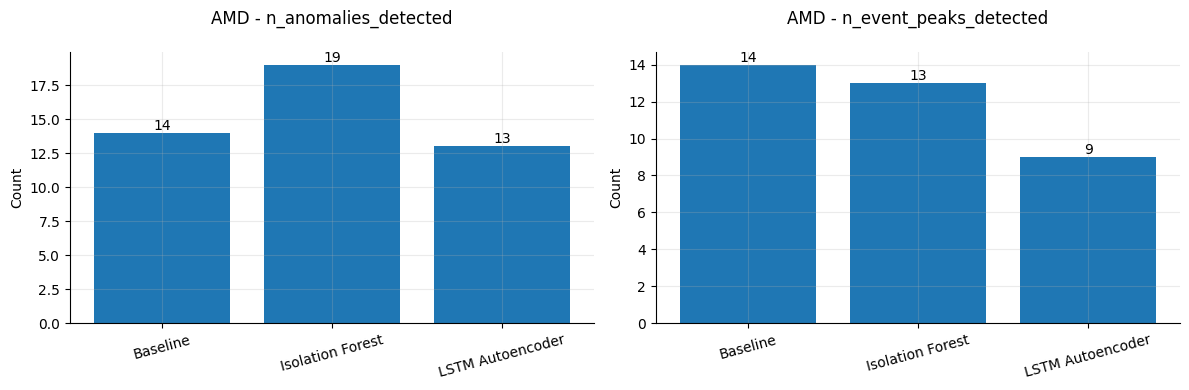

In [13]:
plot_method_price_comparison(PRIMARY_SERIES, comparison_df)
plot_method_score_comparison(PRIMARY_SERIES, comparison_df)
plot_method_counts_for_series(comparison_summary, PRIMARY_SERIES)


## 13. Compare all selected series by anomaly count

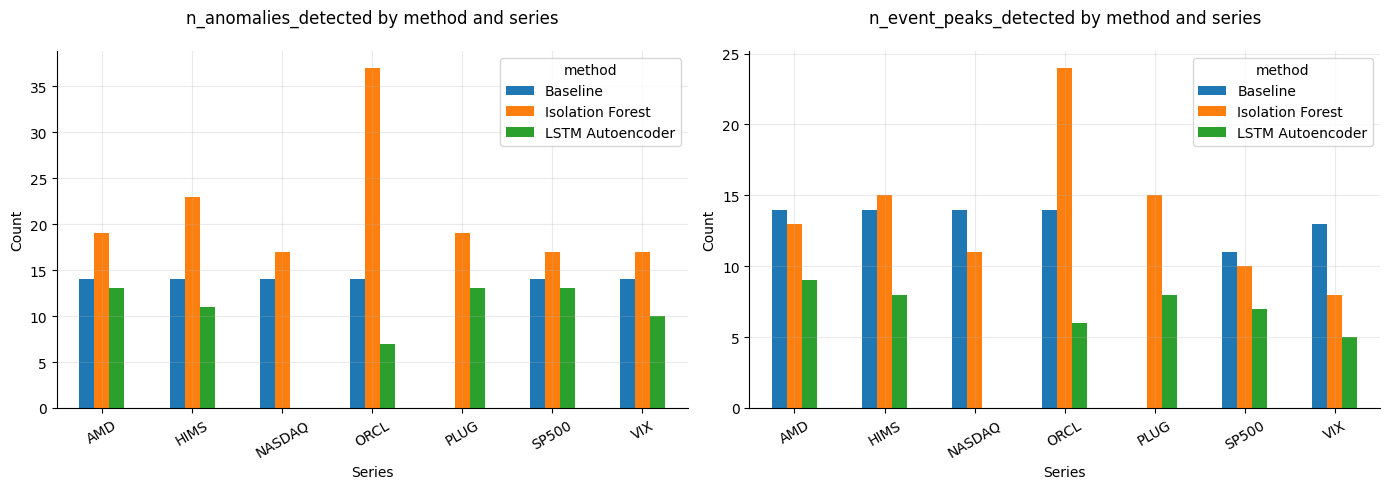

In [14]:
plot_df = comparison_summary.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot = plot_df.pivot(index="SeriesName", columns="method", values="n_anomalies_detected")
pivot.plot(kind="bar", ax=axes[0])
axes[0].set_title("n_anomalies_detected by method and series", pad=20)
axes[0].set_xlabel("Series")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

pivot = plot_df.pivot(index="SeriesName", columns="method", values="n_event_peaks_detected")
pivot.plot(kind="bar", ax=axes[1])
axes[1].set_title("n_event_peaks_detected by method and series", pad=20)
axes[1].set_xlabel("Series")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


## 14. Build a daily agreement table

This section shows where methods agree or disagree on anomaly dates for the same instrument.


In [15]:
def build_daily_method_flags(series_name: str, df_in: pd.DataFrame) -> pd.DataFrame:
    out = (
        df_in[df_in["SeriesName"] == series_name]
        .pivot_table(
            index=["Date", "SeriesName", "Ticker", "Price"],
            columns="method",
            values="is_anomaly_detected",
            aggfunc="max",
        )
        .reset_index()
    )

    for c in ["Baseline", "Isolation Forest", "LSTM Autoencoder"]:
        if c not in out.columns:
            out[c] = False

    out["n_methods_detected"] = (
        out[["Baseline", "Isolation Forest", "LSTM Autoencoder"]]
        .fillna(False)
        .astype(int)
        .sum(axis=1)
    )
    return out.sort_values("Date").reset_index(drop=True)


agreement_df = build_daily_method_flags(PRIMARY_SERIES, comparison_df)
display(agreement_df.tail(20))


method,Date,SeriesName,Ticker,Price,Baseline,Isolation Forest,LSTM Autoencoder,n_methods_detected
1298,2026-03-06,AMD,AMD,192.429993,False,False,False,0
1299,2026-03-09,AMD,AMD,202.679993,False,False,False,0
1300,2026-03-10,AMD,AMD,203.229996,False,False,False,0
1301,2026-03-11,AMD,AMD,204.830002,False,False,False,0
1302,2026-03-12,AMD,AMD,197.740005,False,False,False,0
1303,2026-03-13,AMD,AMD,193.389999,False,False,False,0
1304,2026-03-16,AMD,AMD,196.580002,False,False,False,0
1305,2026-03-17,AMD,AMD,196.309998,False,False,False,0
1306,2026-03-18,AMD,AMD,199.460007,False,False,False,0
1307,2026-03-19,AMD,AMD,205.270004,False,False,False,0


## 15. Plot consensus anomalies for the selected series

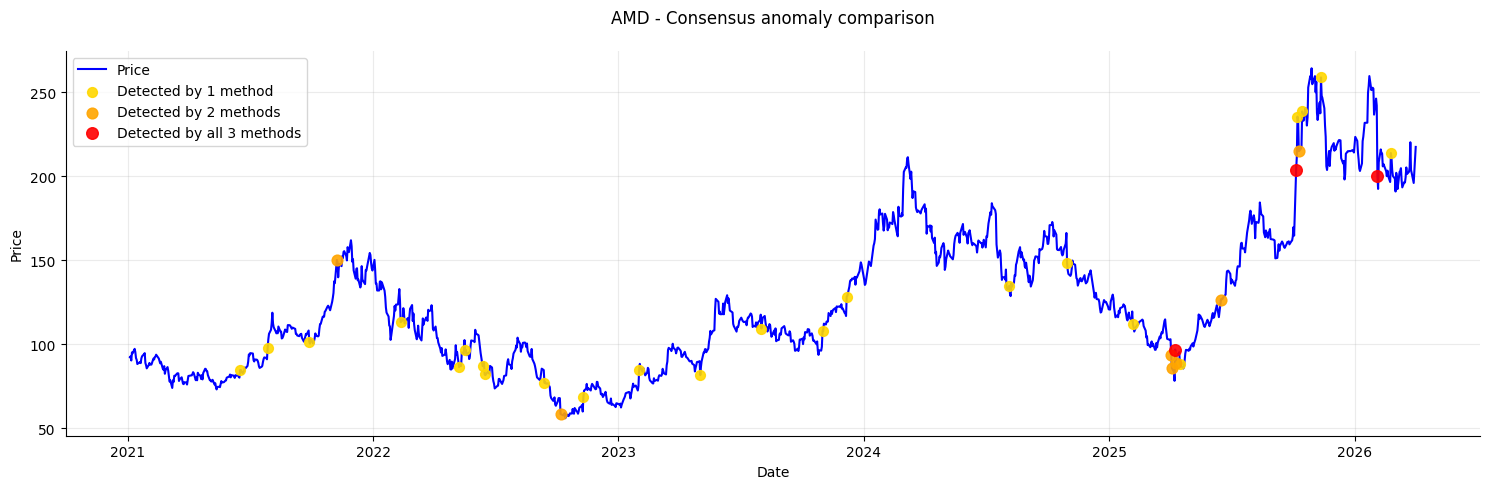

In [16]:
def plot_consensus_anomalies(series_name: str, df_in: pd.DataFrame):
    daily = build_daily_method_flags(series_name, df_in)
    base_group = get_method_series_data(df_in, "Baseline", series_name)

    merged = daily.merge(
        base_group[["Date", "Price"]],
        on="Date",
        how="left",
        suffixes=("", "_base")
    )
    if "Price_x" in merged.columns and "Price_y" in merged.columns:
        merged["Price"] = merged["Price_x"].fillna(merged["Price_y"])

    plt.figure(figsize=(15, 5))
    plt.plot(base_group["Date"], base_group["Price"], color="blue", linewidth=1.5, label="Price")

    for n, color, label in [
        (1, "gold", "Detected by 1 method"),
        (2, "orange", "Detected by 2 methods"),
        (3, "red", "Detected by all 3 methods"),
    ]:
        sub = merged[merged["n_methods_detected"] == n]
        if not sub.empty:
            plt.scatter(sub["Date"], sub["Price"], color=color, s=40 + 10*n, alpha=0.9, label=label, zorder=4)

    plt.title(f"{series_name} - Consensus anomaly comparison", pad=20)
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_consensus_anomalies(PRIMARY_SERIES, comparison_df)


## 16. Inspect the top anomaly dates by method for the selected series

In [17]:
def top_anomaly_table(series_name: str, df_in: pd.DataFrame, n: int = 15):
    sub = df_in[(df_in["SeriesName"] == series_name) & (df_in["is_anomaly_detected"])].copy()
    cols = [c for c in [
        "method", "Date", "SeriesName", "Ticker", "Price",
        "score", "threshold", "is_event_peak_detected",
        "simple_return", "return_5d", "vol_20", "volume_z_20",
        "SP500_simple_return", "NASDAQ_simple_return", "VIX_simple_return"
    ] if c in sub.columns]

    display(sub.sort_values(["method", "score"], ascending=[True, False])[cols].head(n * 3))

top_anomaly_table(PRIMARY_SERIES, comparison_df, n=10)


,method,Date,SeriesName,Ticker,Price,score,threshold,is_event_peak_detected,simple_return,return_5d,vol_20,volume_z_20,SP500_simple_return,NASDAQ_simple_return,VIX_simple_return
1194,Baseline,2025-10-06,AMD,AMD,203.710007,3.982930,2.868576,True,0.237080,0.262457,0.048188,3.692934,0.003647,0.007074,-0.016817
1277,Baseline,2026-02-04,AMD,AMD,200.190002,3.310795,2.868576,True,-0.173144,-0.207921,0.052635,2.759174,-0.005072,-0.015077,0.035556
586,Baseline,2023-05-03,AMD,AMD,81.620003,3.257744,2.868576,True,-0.092203,-0.050268,0.027537,3.344011,-0.006998,-0.004568,0.031496
712,Baseline,2023-11-01,AMD,AMD,108.040001,3.127827,2.868576,True,0.096853,0.124714,0.030797,3.563729,0.010506,0.016359,-0.070011
737,Baseline,2023-12-07,AMD,AMD,128.369995,3.082205,2.868576,True,0.098870,0.059508,0.026657,2.556543,0.007968,0.013663,0.006939
1071,Baseline,2025-04-09,AMD,AMD,96.839996,3.076296,2.868576,True,0.238205,-0.059441,0.063068,2.275477,0.095154,0.121632,-0.357539
185,Baseline,2021-09-28,AMD,AMD,101.519997,3.068835,2.868576,True,-0.061391,-0.012643,0.018648,2.878469,-0.020364,-0.028276,0.239339
1117,Baseline,2025-06-16,AMD,AMD,126.389999,3.044157,2.868576,True,0.088068,0.038281,0.028081,3.448599,0.009393,0.015169,-0.082133
444,Baseline,2022-10-07,AMD,AMD,58.439999,3.015879,2.868576,True,-0.138688,-0.077652,0.043478,3.060043,-0.028004,-0.038011,0.027523
114,Baseline,2021-06-17,AMD,AMD,84.559998,2.986651,2.868576,True,0.055549,0.036783,0.016368,2.987941,-0.000436,0.008666,-0.022039


## 17. Save the consensus table

In [18]:
agreement_df.to_csv(CONSENSUS_PATH, index=False)
print(f"Saved consensus table to: {CONSENSUS_PATH}")


Saved consensus table to: results\notebooks\method_comparison\method_consensus_table.csv


## 18. Suggested interpretation for the report

This comparison notebook helps answer questions such as:

- Which method is the most sensitive?
- Which method produces the fewest event peaks?
- Do the methods agree on the same market episodes?
- Does the LSTM focus more on regime-like sequences than point anomalies?
- Does the baseline method over-flag extreme single-day behavior?
- Does Isolation Forest sit between the baseline and the LSTM in sensitivity?

Recommended terminology:

- **n_anomalies_detected** = raw anomaly dates flagged by a method
- **n_event_peaks_detected** = clustered representative anomaly dates
- **event peak** = highest-scoring anomaly inside a nearby anomaly cluster
- **consensus anomaly** = date flagged by more than one method

A strong final report section can discuss:
1. method sensitivity,
2. method interpretability,
3. overlap in detected episodes,
4. and the trade-off between simple and deep models.
